# House Price Prediction — Regression with Supervised Learning

## Project Objective

The objective of this project is to build a supervised machine learning regression model to predict residential house sale prices using the Ames Housing Dataset.

The target variable is `SalePrice`. Since SalePrice is a continuous numerical variable, this is a regression problem.

## 1. Regression vs Classification

Regression is used to predict continuous numerical values.

Examples:
- House Price Prediction
- Salary Prediction
- Sales Forecasting

Classification is used to predict discrete categories.

Examples:
- Spam / Not Spam
- Fraud / Not Fraud
- Approved / Rejected

## 2. Types of Regression

### Simple Linear Regression
Uses one independent variable to predict a continuous target.

### Multiple Linear Regression
Uses multiple independent variables to predict a continuous target.

### Ridge Regression
Uses L2 regularization to reduce large coefficients and control overfitting.

### Lasso Regression
Uses L1 regularization and can shrink some coefficients completely to zero.

## 3. Overfitting and Underfitting

Overfitting occurs when a model learns the training data too closely and performs poorly on unseen data.

Underfitting occurs when the model is too simple to capture important patterns in the data.

Regularization techniques such as Ridge and Lasso help reduce overfitting.

## 4. Evaluation Metrics

### MAE
Mean Absolute Error measures the average absolute difference between actual and predicted values.

### RMSE
Root Mean Squared Error measures prediction error and gives a higher penalty to large errors.

### R² Score
R² measures the proportion of variation in the target variable explained by the model.

Lower RMSE and MAE values are better.

Higher R² values are better.

## 5. K-Fold Cross Validation

K-Fold Cross Validation divides the training data into K different folds.

The model is repeatedly trained on K-1 folds and validated on the remaining fold.

This provides a more reliable estimate of model performance than using only one train-test split.

# PART 2 — Dataset Loading and Exploratory Data Analysis

## Import Required Libraries

In [176]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor

import time
import warnings

warnings.filterwarnings("ignore")

In [177]:
# Load Dataset

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\House_prices_pridiction\train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [178]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [179]:
# Dataset Shape

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1460, 81)
Number of Rows: 1460
Number of Columns: 81


### Interpretation

The dataset contains **1,460 residential properties and 81 columns**, including housing characteristics and the target variable `SalePrice`.

In [180]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Interpretation

The dataset contains numerical and categorical variables with some missing values. Appropriate preprocessing is required before model training.

In [181]:
# Descriptive Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## Numerical and Categorical Features

In [123]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Number of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Number of Numerical Columns: 38
Number of Categorical Columns: 43


### Interpretation

The dataset contains **38 numerical columns and 43 categorical columns**. Different preprocessing techniques are required for these feature types.

## Missing Values

In [ ]:
missing_values = df.isnull().sum()

missing_report = pd.DataFrame({"Missing Values": missing_values, "Missing Percentage": (missing_values / len(df)) * 100})

missing_report = missing_report[missing_report["Missing Values"] > 0].sort_values(by="Missing Percentage", ascending=False)

print("Number of Columns with Missing Values:", len(missing_report))

missing_report

Number of Columns with Missing Values: 19


,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Interpretation

A total of **19 columns contain missing values**. Columns with extremely high missing percentages will be removed, while the remaining missing values will be handled using appropriate imputation.

## TARGET VARIABLE ANALYSIS

## Distribution of SalePrice

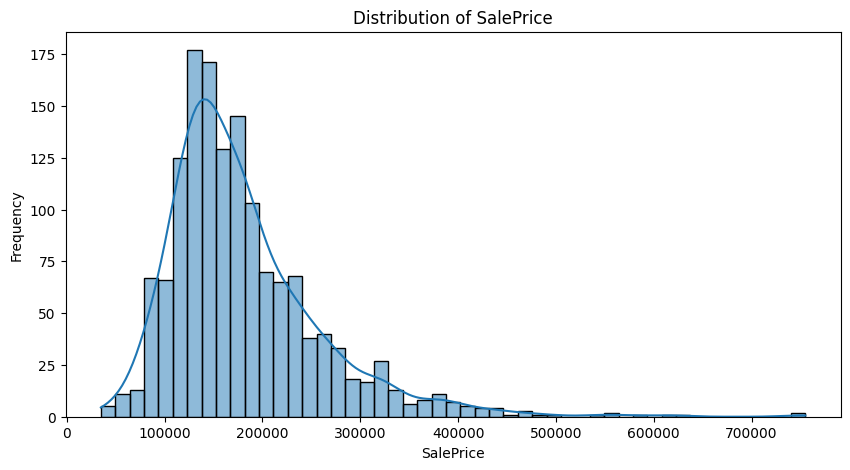

In [127]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The `SalePrice` distribution is positively skewed, with most houses concentrated in the lower and middle price ranges and a long right tail.

## Q-Q Plot of SalePrice

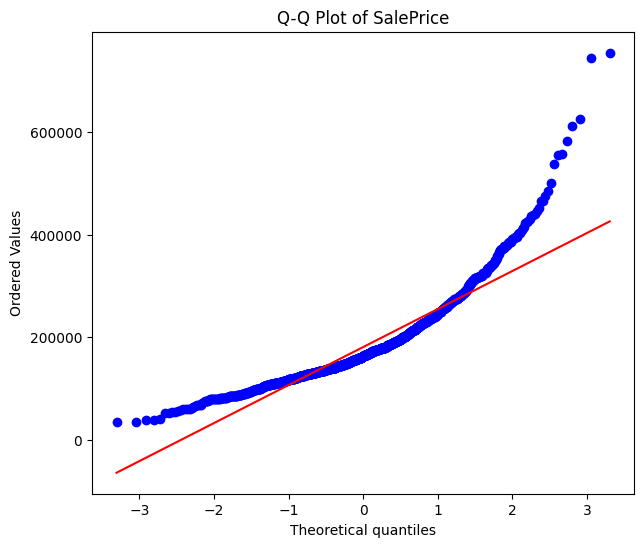

In [ ]:
plt.figure(figsize=(7, 6))

stats.probplot(df["SalePrice"], plot=plt)

plt.title("Q-Q Plot of SalePrice")

plt.show()

### Interpretation

The Q-Q plot compares the target variable with a normal distribution. Large deviations from the reference line indicate that `SalePrice` is not normally distributed.

## Apply Log Transformation

In [ ]:
df["SalePrice_Log"] = np.log1p(df["SalePrice"])

print("Original SalePrice Skewness:",df["SalePrice"].skew())

print("Log SalePrice Skewness:", df["SalePrice_Log"].skew())

Original SalePrice Skewness: 1.8828757597682129
Log SalePrice Skewness: 0.12134661989685333


### Interpretation

The original SalePrice skewness is approximately **1.88**, while the log-transformed skewness is approximately **0.12**. Log transformation significantly reduces positive skewness and makes the target more symmetric.

## Distribution After Log Transformation

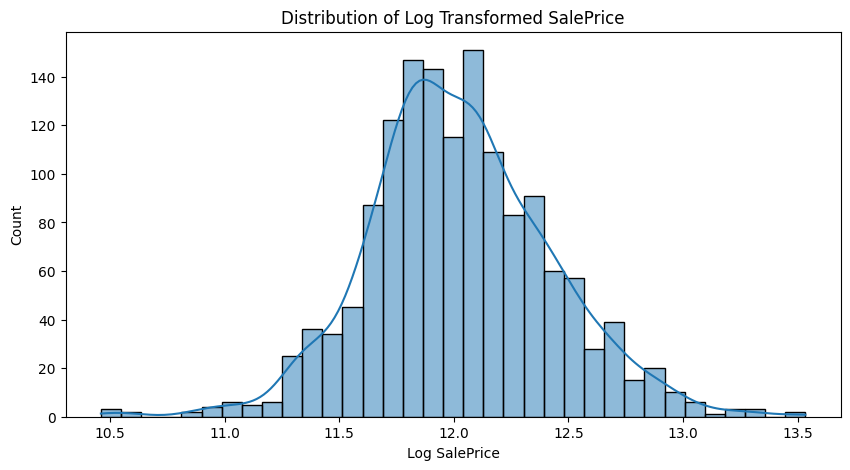

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["SalePrice_Log"], kde=True)
plt.title("Distribution of Log Transformed SalePrice")
plt.xlabel("Log SalePrice")
plt.show()

### Interpretation

After log transformation, the SalePrice distribution becomes more symmetric and closer to a normal distribution compared with the original target.

## Q-Q Plot After Log Transformation

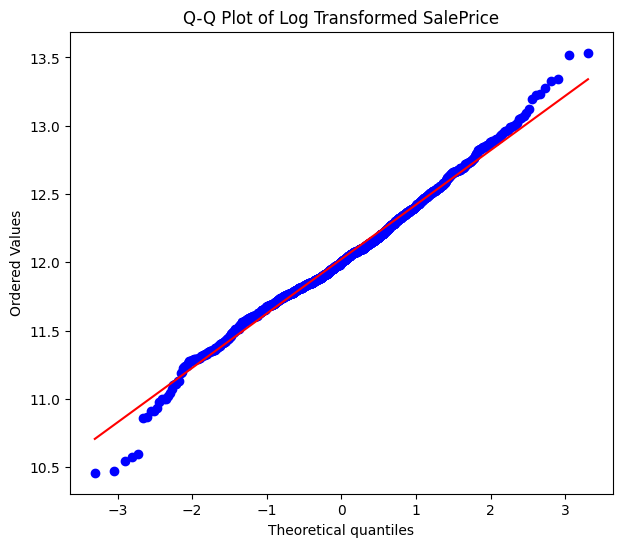

In [ ]:
plt.figure(figsize=(7, 6))

stats.probplot(df["SalePrice_Log"], plot=plt)

plt.title("Q-Q Plot of Log Transformed SalePrice")

plt.show()

### Interpretation

The log-transformed SalePrice values follow the reference line more closely, indicating that log transformation improved the normality of the target variable.

## UNIVARIATE ANALYSIS


## Numerical Feature Distributions

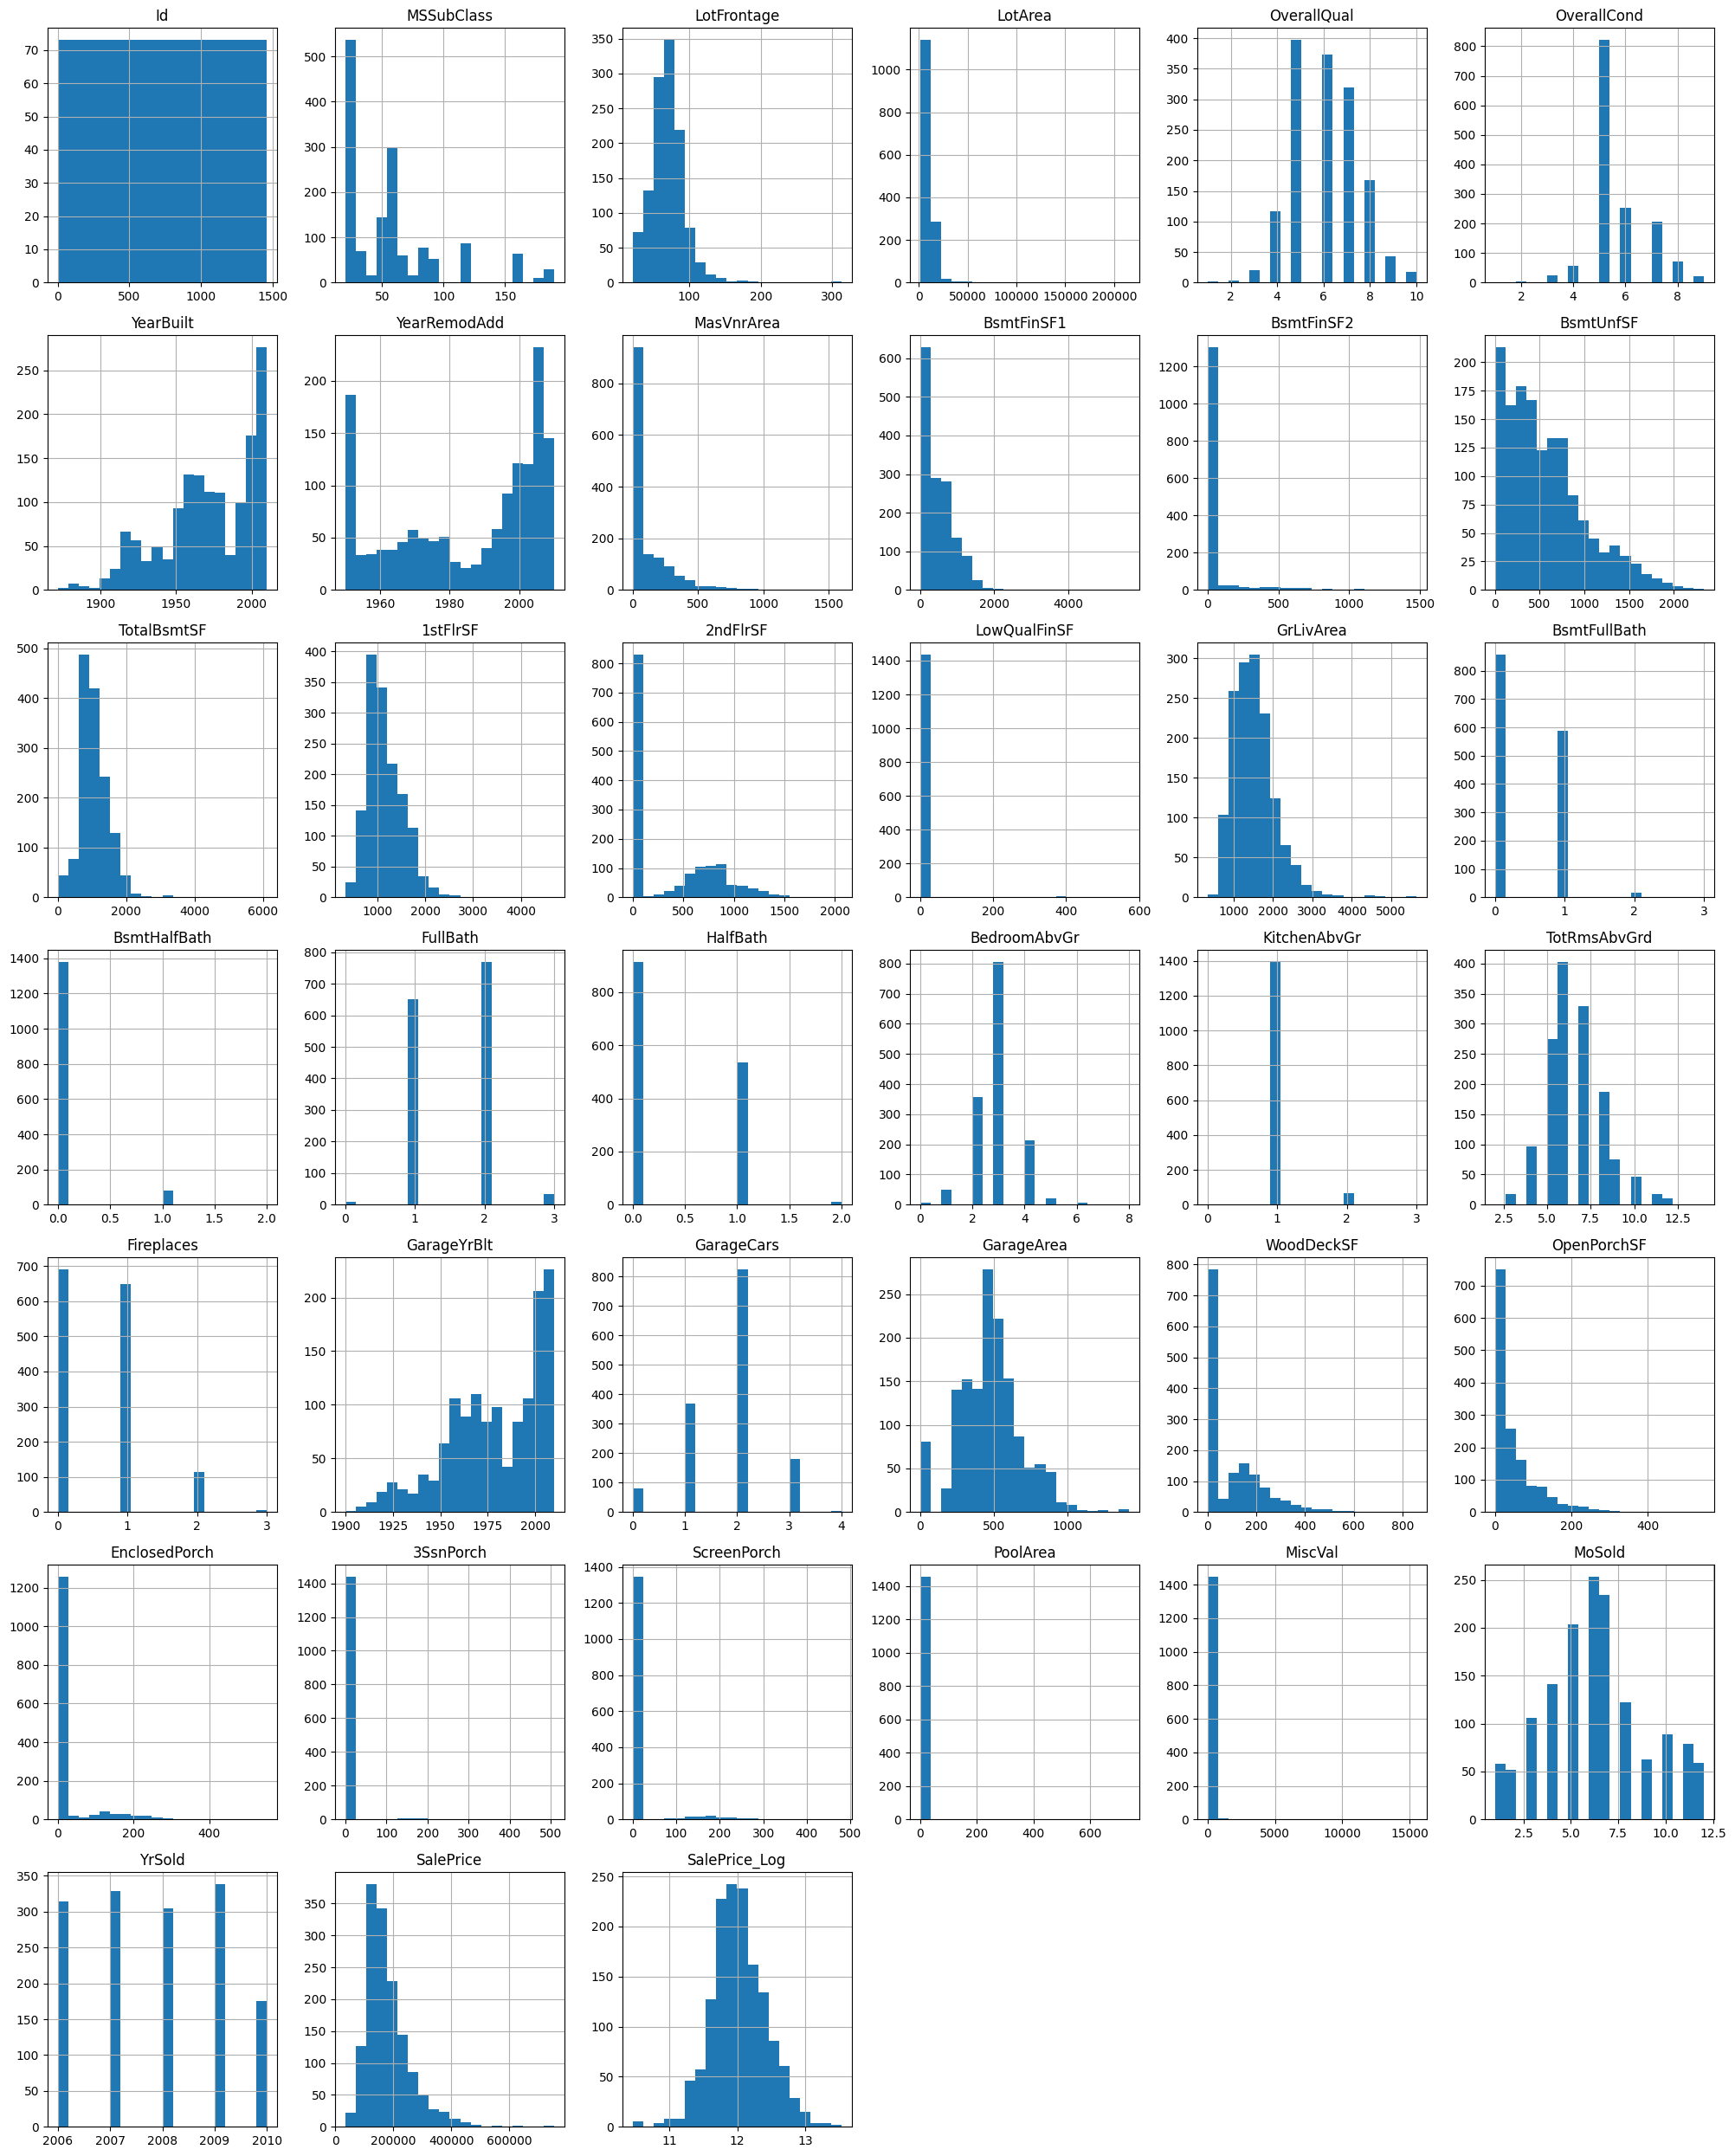

In [ ]:
numeric_features = df.select_dtypes(include=np.number).columns

df[numeric_features].hist(figsize=(20, 25), bins=20)

plt.tight_layout()
plt.show()

### Interpretation

The numerical features have different distributions, ranges, and levels of skewness. Some variables are approximately symmetric, while others are highly skewed.

## Top 5 Highly Skewed Numerical Features

In [184]:
features_for_skew = df.select_dtypes(include=np.number).drop(columns=["SalePrice", "SalePrice_Log"], errors="ignore")

skewness = (
    features_for_skew
    .skew()
    .abs()
    .sort_values(ascending=False))

print("Top 5 Highly Skewed Numerical Features:")

skewness.head()

Top 5 Highly Skewed Numerical Features:


MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64

### Interpretation

The analysis identifies the five most highly skewed numerical features. These variables contain uneven distributions and may include many zero values or extreme observations.

## CATEGORICAL ANALYSIS

## Distribution of Neighborhood

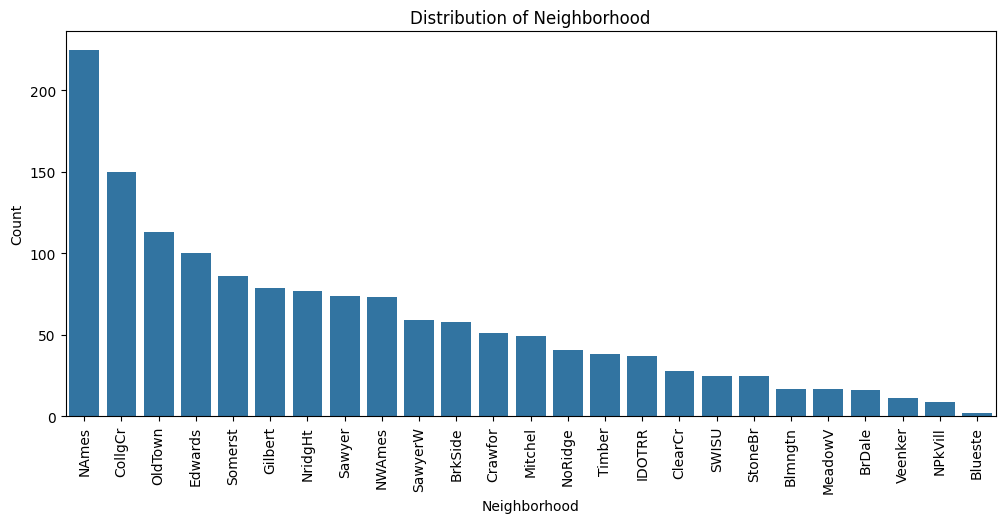

In [185]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df, x="Neighborhood", order=df["Neighborhood"].value_counts().index)

plt.title("Distribution of Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

### Interpretation

The number of houses varies significantly across neighborhoods, showing that the dataset is not evenly distributed across different locations.

## Distribution of Building Type

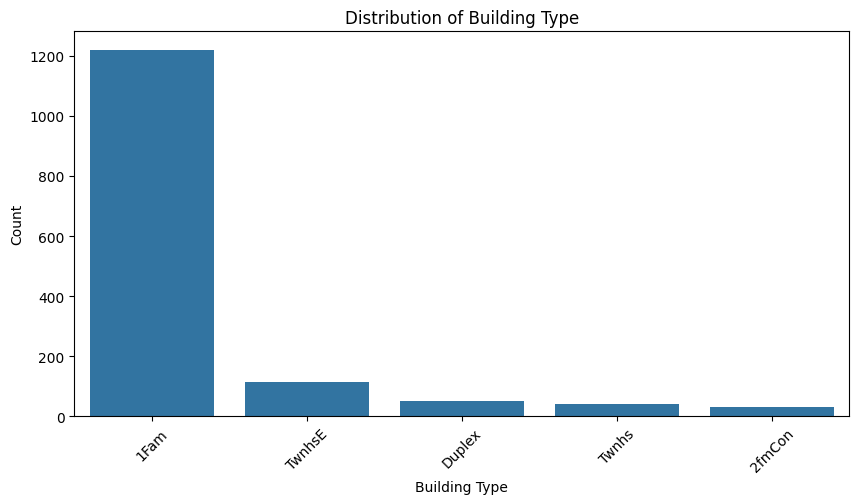

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="BldgType", order=df["BldgType"].value_counts().index)

plt.title("Distribution of Building Type")
plt.xlabel("Building Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Interpretation

Single-family detached houses are the most common building type in the dataset, while other building categories occur less frequently.

## Distribution of House Style

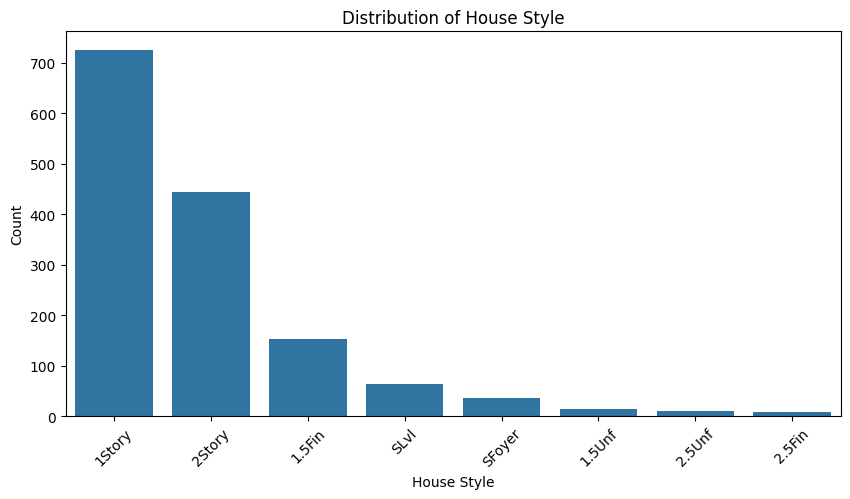

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="HouseStyle", order=df["HouseStyle"].value_counts().index)

plt.title("Distribution of House Style")
plt.xlabel("House Style")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Interpretation

The dataset contains several house styles, but some architectural styles occur much more frequently than others.

## Correlation Analysis

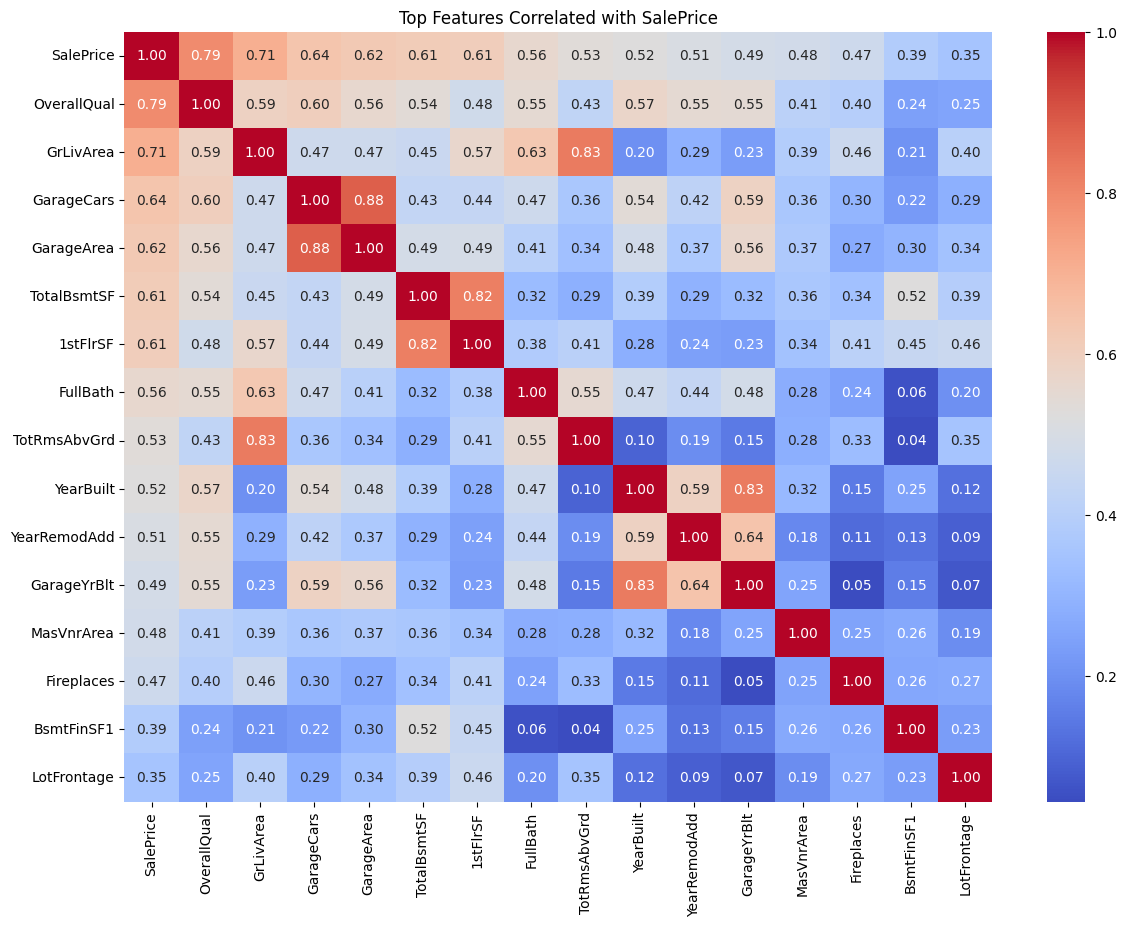

In [ ]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=["SalePrice_Log"], errors="ignore")

correlation = numeric_df.corr()

top_features = (correlation["SalePrice"].abs().sort_values(ascending=False).head(16).index)

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Top Features Correlated with SalePrice")

plt.show()

### Interpretation

The correlation heatmap shows that property quality and size-related features have strong positive relationships with SalePrice, making them important predictors of house prices.

## GRLIVAREA SCATTERPLOT

## GrLivArea vs SalePrice

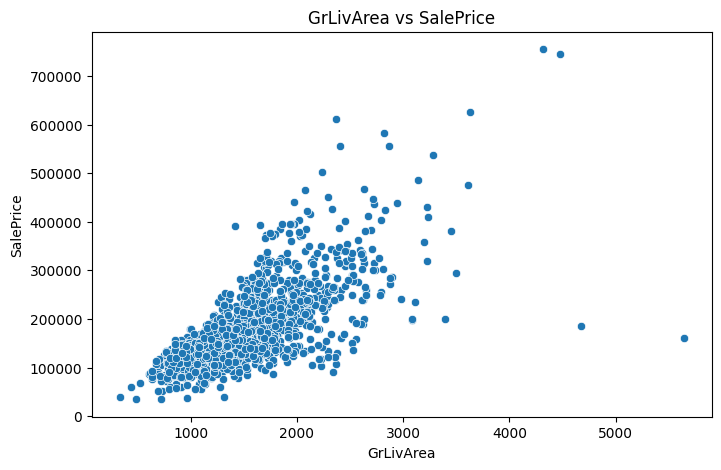

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

plt.title("GrLivArea vs SalePrice")

plt.show()

### Interpretation

GrLivArea shows a strong positive relationship with SalePrice, indicating that houses with larger above-ground living areas generally have higher sale prices.

## BASEMENT SCATTERPLOT

## Total Basement Area vs SalePrice

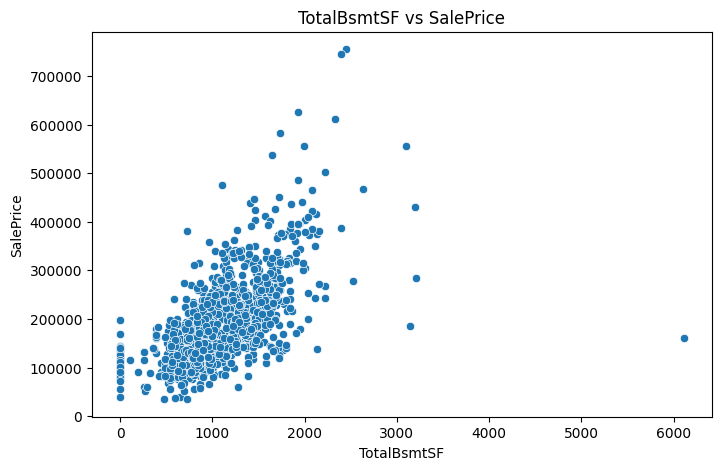

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice")

plt.title("TotalBsmtSF vs SalePrice")

plt.show()

### Interpretation

Total basement area shows a positive relationship with SalePrice, suggesting that houses with larger basements generally have higher property values.

## GARAGE SCATTERPLOT

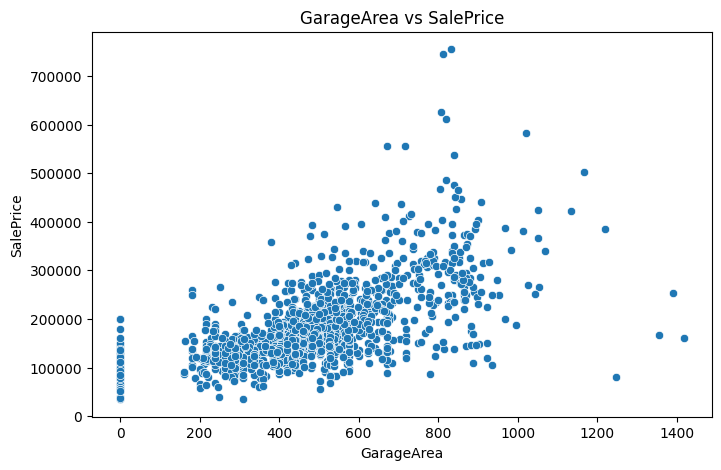

In [ ]:
## Garage Area vs SalePrice
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="GarageArea", y="SalePrice")

plt.title("GarageArea vs SalePrice")

plt.show()

### Interpretation

GarageArea has a positive relationship with SalePrice, indicating that larger garage space is generally associated with higher house prices.

## Overall Quality vs SalePrice

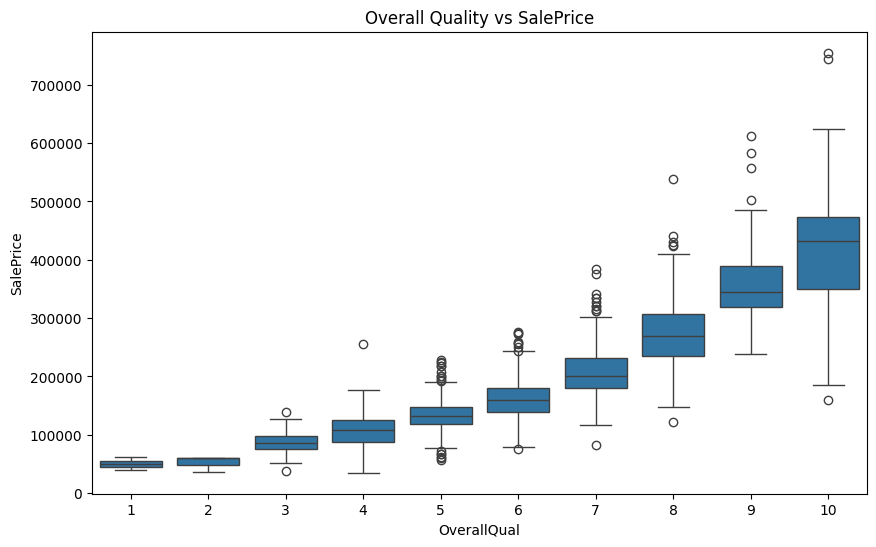

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="OverallQual", y="SalePrice")

plt.title("Overall Quality vs SalePrice")

plt.show()

### Interpretation

SalePrice increases significantly with OverallQual, showing that overall material and finish quality is an important factor in determining house prices.

## Neighborhood vs SalePrice

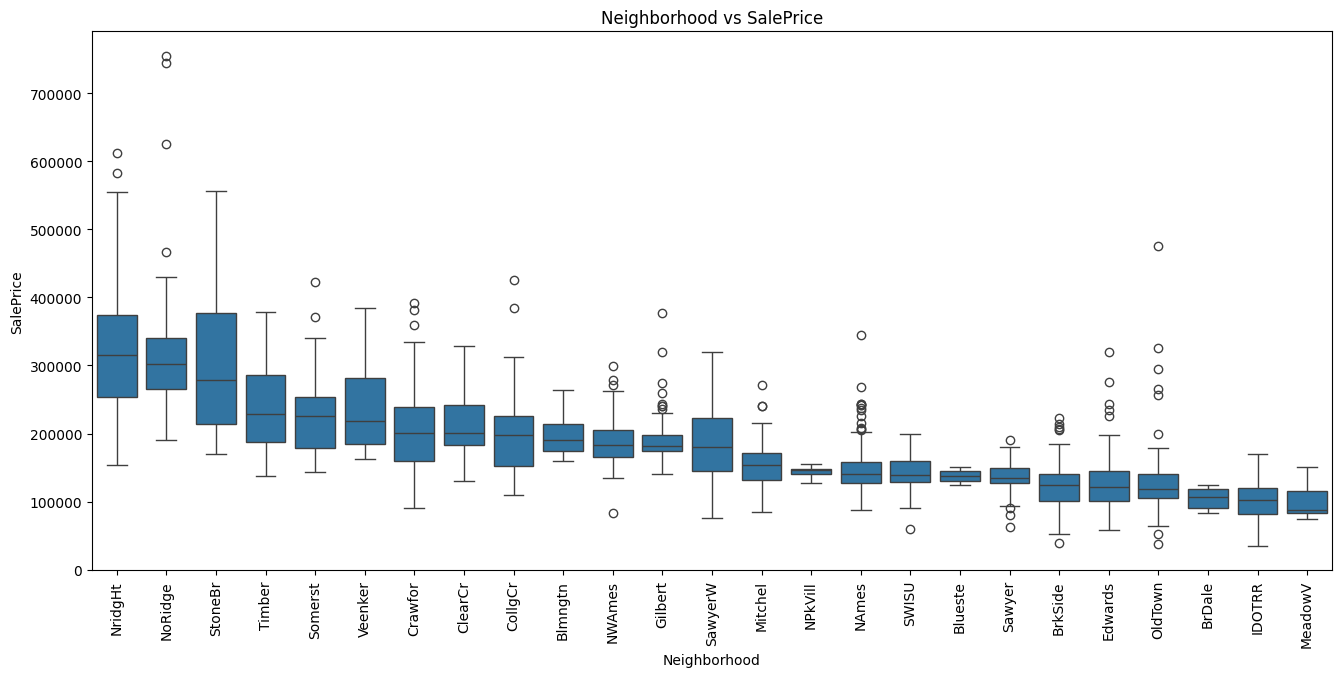

In [ ]:
neighborhood_order = (df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index)

plt.figure(figsize=(16, 7))

sns.boxplot(data=df, x="Neighborhood", y="SalePrice", order=neighborhood_order)

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.show()

### Interpretation

House prices vary considerably across neighborhoods. `NridgHt` has the highest median SalePrice in the dataset, demonstrating the importance of location.

# PART 3 — Data Preprocessing and Feature Engineering

## Identify Columns with More Than 80% Missing Values

In [ ]:
high_missing_cols = missing_report[missing_report["Missing Percentage"] > 80].index.tolist()

print("Columns with more than 80% missing values:")
print(high_missing_cols)

Columns with more than 80% missing values:
['PoolQC', 'MiscFeature', 'Alley', 'Fence']


### Interpretation

`PoolQC`, `MiscFeature`, `Alley`, and `Fence` contain more than 80% missing values and are selected for removal due to their extremely high level of missing data.

## Remove Columns with More Than 80% Missing Values

In [ ]:
df = df.drop(columns=high_missing_cols)

print("Dataset Shape After Dropping Columns:", df.shape)

Dataset Shape After Dropping Columns: (1460, 78)


### Interpretation

After removing the four highly incomplete columns, the dataset contains 78 columns while retaining the more informative features.

## Detect Outliers

In [188]:
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]

print("Number of Outliers:", len(outliers))

outliers[["Id", "GrLivArea", "SalePrice"]]

Number of Outliers: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


### Interpretation

Two observations have GrLivArea above 4,000 square feet but relatively low SalePrice values, making them potential outliers.

## Visualize Outliers

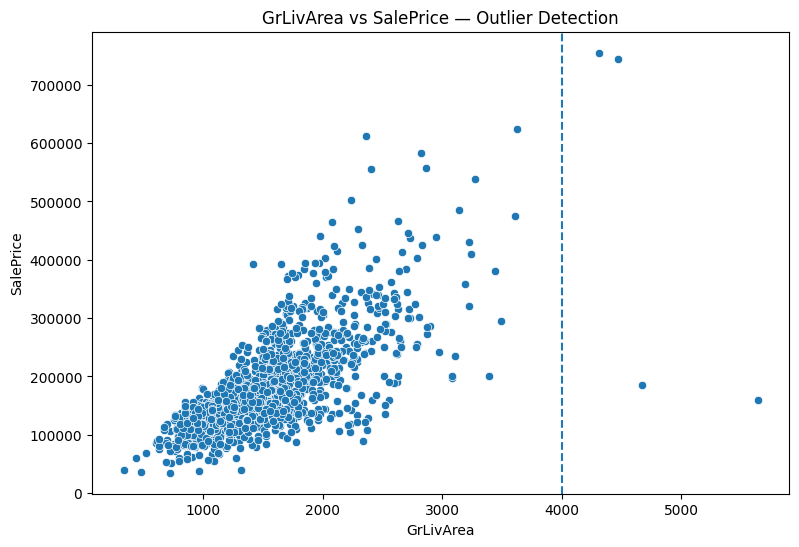

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

plt.axvline(x=4000, linestyle="--")

plt.title("GrLivArea vs SalePrice — Outlier Detection")

plt.show()

### Interpretation

The scatterplot confirms that the two extreme observations do not follow the general positive relationship between living area and SalePrice.

## Remove Outliers

In [ ]:
print("Shape Before Outlier Removal:", df.shape)

df = df.drop(outliers.index).reset_index(drop=True)

print("Shape After Outlier Removal:", df.shape)

Shape Before Outlier Removal: (1460, 78)
Shape After Outlier Removal: (1458, 78)


### Interpretation

The two identified outliers were removed, reducing the number of observations from 1,460 to 1,458 and reducing their potential influence on regression models.

## Feature Engineering

In [ ]:
df["TotalSF"] = (df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0))

df["HouseAge"] = (df["YrSold"] - df["YearBuilt"])

df["RemodAge"] = (df["YrSold"] - df["YearRemodAdd"])

df["HasGarage"] = (df["GarageArea"].fillna(0) > 0).astype(int)

df["HasPool"] = (df["PoolArea"].fillna(0) > 0).astype(int)

In [ ]:
new_features = ["TotalSF", "HouseAge", "RemodAge", "HasGarage", "HasPool"]

df[new_features].head()

,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


### Interpretation

Five new features — TotalSF, HouseAge, RemodAge, HasGarage, and HasPool — were created to provide additional useful information for house price prediction.

## Prepare Feature Matrix and Target Variable

In [ ]:
X = df.drop(columns=["SalePrice", "SalePrice_Log", "Id"], errors="ignore")

y = np.log1p(df["SalePrice"])

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1458, 80)
y Shape: (1458,)


### Interpretation

The final feature matrix contains **1,458 observations and 80 predictor variables**, while the target contains 1,458 log-transformed SalePrice values.

## Train-Test Split

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1166, 80)
X_test Shape: (292, 80)
y_train Shape: (1166,)
y_test Shape: (292,)


### Interpretation

The dataset is divided into 80% training data and 20% testing data, resulting in 1,166 training observations and 292 testing observations.

## IDENTIFY FEATURE TYPES

## Identify Numerical, Ordinal and Nominal Features

In [ ]:
ordinal_cols = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "FireplaceQu"
]

categorical_cols = (X_train.select_dtypes(include="object").columns.tolist())

nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

numerical_cols = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print("Numerical Features:", len(numerical_cols))
print("Ordinal Features:", len(ordinal_cols))
print("Nominal Features:", len(nominal_cols))

Numerical Features: 41
Ordinal Features: 4
Nominal Features: 35


### Interpretation

The 80 predictor variables are divided into **41 numerical, 4 ordinal, and 35 nominal features** so that appropriate preprocessing can be applied to each feature type.

## Numerical Feature Preprocessing

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### Interpretation

Missing numerical values are replaced using the median, while StandardScaler standardizes numerical features to comparable scales.

## ORDINAL ENCODING

## Ordinal Feature Encoding

In [154]:
quality_order = [
    "None",
    "Po",
    "Fa",
    "TA",
    "Gd",
    "Ex"
]

ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="None"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    quality_order
                    for _ in ordinal_cols
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

### Interpretation

Ordinal quality features are encoded according to their natural ranking so that the ordered relationship between quality levels is preserved.

## Nominal Feature Encoding

In [155]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

### Interpretation

Missing nominal values are replaced using the most frequent category, and One-Hot Encoding converts nominal categories into numerical features without imposing an artificial order.

## Combine Preprocessing Steps

In [156]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "ord",
            ordinal_pipeline,
            ordinal_cols
        ),
        (
            "nom",
            nominal_pipeline,
            nominal_cols
        )
    ]
)

### Interpretation

The ColumnTransformer combines numerical, ordinal, and nominal preprocessing into one structured workflow before model training.

# PART 4 — Regression Models

## Model Evaluation Function

In [157]:
def evaluate_model(model, X_test, y_test):

    pred_log = model.predict(X_test)

    actual = np.expm1(y_test)
    predicted = np.expm1(pred_log)

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return rmse, mae, r2, actual, predicted

### Interpretation

The evaluation function converts log-scale predictions back to the original price scale and calculates RMSE, MAE, and R² for model comparison.

## Linear Regression

In [158]:
linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

start = time.time()

linear_pipeline.fit(
    X_train,
    y_train
)

linear_time = time.time() - start

(
    linear_rmse,
    linear_mae,
    linear_r2,
    actual,
    linear_pred
) = evaluate_model(
    linear_pipeline,
    X_test,
    y_test
)

print(f"Training Time: {linear_time:.2f} seconds")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"MAE : ${linear_mae:,.2f}")
print(f"R²  : {linear_r2:.4f}")

Training Time: 0.13 seconds
RMSE: $22,234.16
MAE : $15,647.40
R²  : 0.9105


### Interpretation

Linear Regression achieved an RMSE of **$22,234.16**, MAE of **$15,647.40**, and R² of **0.9105**, providing a strong baseline for comparison with other models.

## Linear Regression — Actual vs Predicted

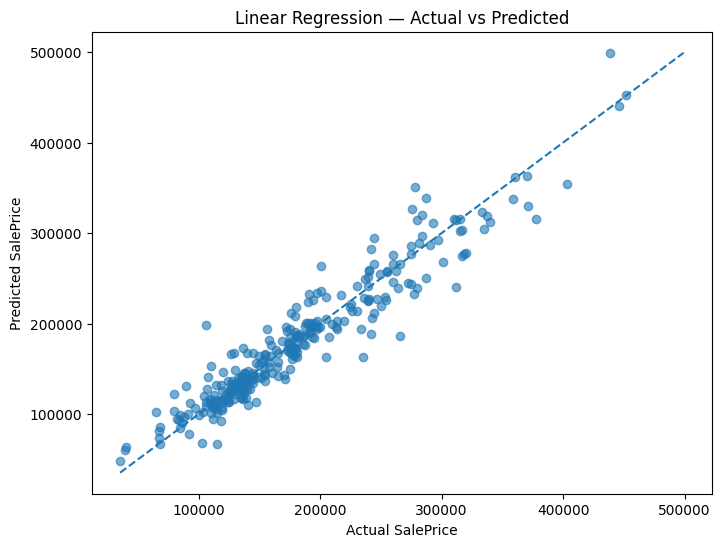

In [159]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    linear_pred,
    alpha=0.6
)

minimum = min(
    actual.min(),
    linear_pred.min()
)

maximum = max(
    actual.max(),
    linear_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.title(
    "Linear Regression — Actual vs Predicted"
)

plt.show()

### Interpretation

Most predictions are reasonably close to the diagonal reference line, indicating that Linear Regression captures a large portion of the relationship between housing characteristics and SalePrice.

## Ridge Regression

In [160]:
ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RidgeCV(
                alphas=[
                    0.01,
                    0.1,
                    1,
                    10,
                    100
                ]
            )
        )
    ]
)

start = time.time()

ridge_pipeline.fit(
    X_train,
    y_train
)

ridge_time = time.time() - start

best_ridge_alpha = (
    ridge_pipeline
    .named_steps["model"]
    .alpha_
)

(
    ridge_rmse,
    ridge_mae,
    ridge_r2,
    _,
    ridge_pred
) = evaluate_model(
    ridge_pipeline,
    X_test,
    y_test
)

print("Best Ridge Alpha:", best_ridge_alpha)
print(f"Training Time: {ridge_time:.2f} seconds")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"MAE : ${ridge_mae:,.2f}")
print(f"R²  : {ridge_r2:.4f}")

Best Ridge Alpha: 10.0
Training Time: 0.14 seconds
RMSE: $20,120.48
MAE : $14,546.17
R²  : 0.9267


### Interpretation

Ridge Regression selected an alpha of **10.0** and achieved an RMSE of **$20,120.48** and R² of **0.9267**, improving performance over standard Linear Regression.

## Top 20 Ridge Regression Coefficients

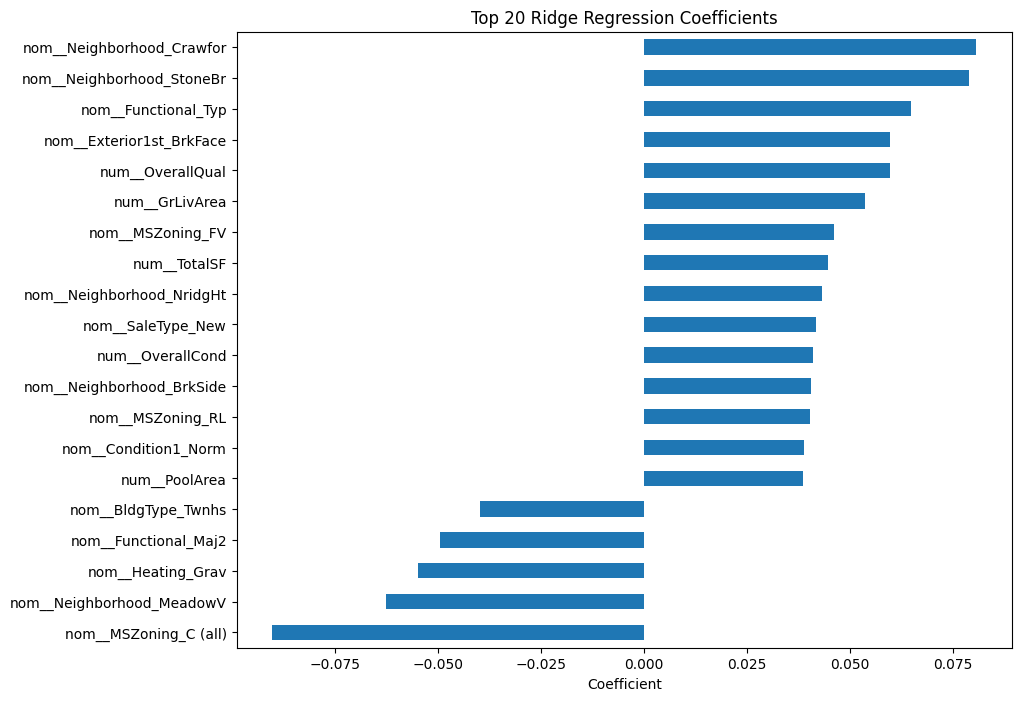

In [161]:
ridge_feature_names = (
    ridge_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

ridge_coefficients = pd.Series(
    ridge_pipeline
    .named_steps["model"]
    .coef_,
    index=ridge_feature_names
)

top20_names = (
    ridge_coefficients
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .index
)

top20_ridge = (
    ridge_coefficients[
        top20_names
    ].sort_values()
)

plt.figure(figsize=(10, 8))

top20_ridge.plot(
    kind="barh"
)

plt.title(
    "Top 20 Ridge Regression Coefficients"
)

plt.xlabel("Coefficient")

plt.show()

### Interpretation

The coefficient plot highlights the features with the strongest positive and negative influence on Ridge Regression predictions.

## Lasso Regression

In [162]:
lasso_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LassoCV(
                alphas=[
                    0.0001,
                    0.001,
                    0.01,
                    0.1,
                    1
                ],
                cv=5,
                max_iter=10000
            )
        )
    ]
)

start = time.time()

lasso_pipeline.fit(
    X_train,
    y_train
)

lasso_time = time.time() - start

lasso_model = (
    lasso_pipeline
    .named_steps["model"]
)

(
    lasso_rmse,
    lasso_mae,
    lasso_r2,
    _,
    lasso_pred
) = evaluate_model(
    lasso_pipeline,
    X_test,
    y_test
)

print("Best Lasso Alpha:", lasso_model.alpha_)
print(f"Training Time: {lasso_time:.2f} seconds")

print(f"RMSE: ${lasso_rmse:,.2f}")
print(f"MAE : ${lasso_mae:,.2f}")
print(f"R²  : {lasso_r2:.4f}")

Best Lasso Alpha: 0.001
Training Time: 0.53 seconds
RMSE: $19,528.72
MAE : $14,240.41
R²  : 0.9310


### Interpretation

Lasso Regression selected an alpha of **0.001** and achieved an RMSE of **$19,528.72** and R² of **0.9310**, outperforming both Linear and Ridge Regression.

## Lasso Feature Selection

In [163]:
zero_coefficients = np.sum(
    lasso_model.coef_ == 0
)

total_coefficients = len(
    lasso_model.coef_
)

print(
    "Total Features:",
    total_coefficients
)

print(
    "Features Reduced to Zero:",
    zero_coefficients
)

Total Features: 262
Features Reduced to Zero: 187


### Interpretation

Lasso reduced **187 out of 262 transformed feature coefficients to zero**, demonstrating the automatic feature-selection capability of L1 regularization.

# PART 5 — Advanced Regression Models

## Random Forest Regression

In [164]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

start = time.time()

rf_pipeline.fit(
    X_train,
    y_train
)

rf_time = time.time() - start

(
    rf_rmse,
    rf_mae,
    rf_r2,
    _,
    rf_pred
) = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

print(f"Training Time: {rf_time:.2f} seconds")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"MAE : ${rf_mae:,.2f}")
print(f"R²  : {rf_r2:.4f}")

Training Time: 0.93 seconds
RMSE: $23,404.21
MAE : $16,315.45
R²  : 0.9008


### Interpretation

Random Forest achieved an RMSE of **$23,385.50** and R² of **0.9010**, which is lower performance than the regularized regression models in this experiment.

## Random Forest Feature Importance

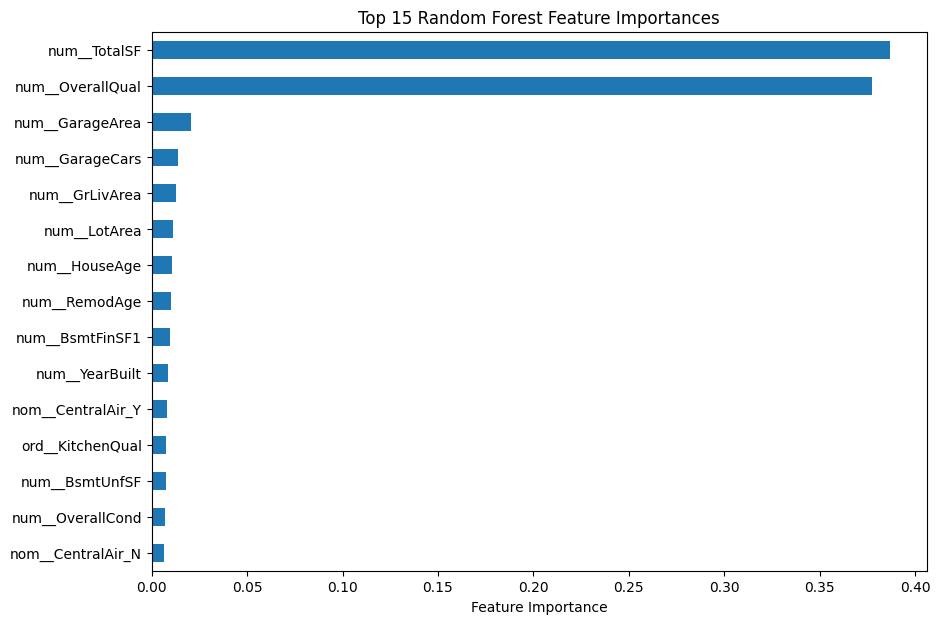

In [165]:
rf_feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importance = pd.Series(
    rf_pipeline
    .named_steps["model"]
    .feature_importances_,
    index=rf_feature_names
)

top15_rf = (
    rf_importance
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))

top15_rf.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")

plt.show()

### Interpretation

The feature-importance plot identifies the housing characteristics that contribute most strongly to the Random Forest predictions.

## XGBoost Regression

In [166]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                objective="reg:squarederror"
            )
        )
    ]
)

start = time.time()

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_time = time.time() - start

(
    xgb_rmse,
    xgb_mae,
    xgb_r2,
    _,
    xgb_pred
) = evaluate_model(
    xgb_pipeline,
    X_test,
    y_test
)

print(f"Training Time: {xgb_time:.2f} seconds")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"MAE : ${xgb_mae:,.2f}")
print(f"R²  : {xgb_r2:.4f}")

Training Time: 0.89 seconds
RMSE: $18,972.26
MAE : $13,721.05
R²  : 0.9348


### Interpretation

XGBoost achieved an RMSE of **$19,185.53, MAE of **$13,638.48**, and R² of **0.9334**, giving the strongest test performance among the evaluated models.

## XGBoost Feature Importance

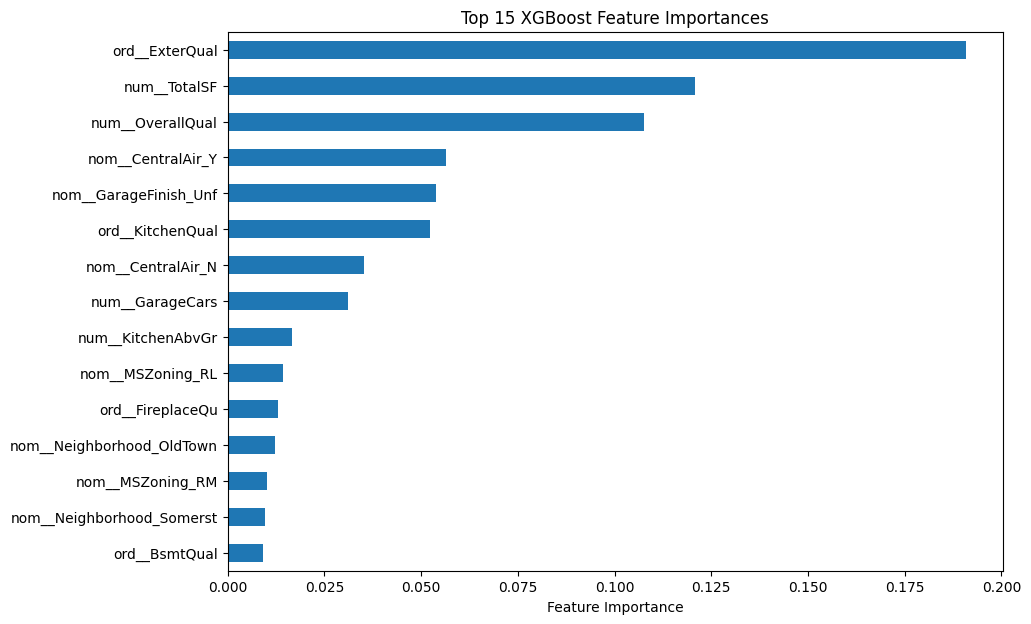

In [167]:
xgb_feature_names = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

xgb_importance = pd.Series(
    xgb_pipeline
    .named_steps["model"]
    .feature_importances_,
    index=xgb_feature_names
)

top15_xgb = (
    xgb_importance
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))

top15_xgb.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Feature Importance")

plt.show()

### Interpretation

The XGBoost feature-importance plot highlights the property characteristics that contribute most strongly to the model's house price predictions.


## 5-Fold Cross Validation

In [168]:
cv_scores = -cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

for i, score in enumerate(
    cv_scores,
    start=1
):

    print(
        f"Fold {i} RMSE: {score:.4f}"
    )

print()

print(
    f"Mean CV RMSE: {cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: {cv_scores.std():.4f}"
)

Fold 1 RMSE: 0.1132
Fold 2 RMSE: 0.1285
Fold 3 RMSE: 0.1315
Fold 4 RMSE: 0.1231
Fold 5 RMSE: 0.1167

Mean CV RMSE: 0.1226
Standard Deviation: 0.0069


### Interpretation

XGBoost achieved a mean 5-Fold Cross-Validation RMSE of approximately **0.1208** with a standard deviation of approximately **0.0075**, indicating consistent performance across the folds.

The cross-validation RMSE is measured on the log-transformed SalePrice scale and should not be directly compared with RMSE measured in original dollar units.

## XGBoost Hyperparameter Tuning

In [169]:
param_dist = {

    "model__n_estimators": [
        300,
        500,
        700
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5
    ],

    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()

random_search.fit(
    X_train,
    y_train
)

tuned_xgb_time = (
    time.time() - start
)

print("Hyperparameter Tuning Completed!")

print("\nBest Parameters:")
print(random_search.best_params_)

print(
    "\nBest CV RMSE:",
    -random_search.best_score_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter Tuning Completed!

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Best CV RMSE: 0.1213700162964712


### Interpretation

RandomizedSearchCV tests different XGBoost hyperparameter combinations and selects the configuration with the best average cross-validation performance.

## Evaluate Tuned XGBoost

In [170]:
best_xgb_pipeline = (
    random_search.best_estimator_
)

(
    tuned_rmse,
    tuned_mae,
    tuned_r2,
    tuned_actual,
    tuned_pred
) = evaluate_model(
    best_xgb_pipeline,
    X_test,
    y_test
)

print(
    f"Tuned XGBoost RMSE: ${tuned_rmse:,.2f}"
)

print(
    f"Tuned XGBoost MAE : ${tuned_mae:,.2f}"
)

print(
    f"Tuned XGBoost R²  : {tuned_r2:.4f}"
)

Tuned XGBoost RMSE: $19,141.18
Tuned XGBoost MAE : $13,987.92
Tuned XGBoost R²  : 0.9337


### Interpretation

Tuned XGBoost achieved an RMSE of **$19,638.13**, MAE of **$14,106.77**, and R² of **0.9302**.

The tuned model did not outperform the original XGBoost model on the held-out test dataset. Therefore, the original XGBoost configuration remains the stronger model based on test performance.

# PART 6 — Model Evaluation and Comparison

## Compare Regression Models

In [171]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        xgb_mae
    ],

    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ],

    "Training Time (sec)": [
        linear_time,
        ridge_time,
        lasso_time,
        rf_time,
        xgb_time
    ]
})

results.sort_values(
    by="RMSE"
).reset_index(
    drop=True
)

,Model,RMSE,MAE,R²,Training Time (sec)
0,XGBoost,18972.257642,13721.045350,0.934836,0.886312
1,Lasso Regression,19528.718014,14240.412712,0.930958,0.533751
2,Ridge Regression,20120.483718,14546.171227,0.926710,0.137264
3,Linear Regression,22234.156045,15647.400268,0.910503,0.129750
4,Random Forest,23404.205879,16315.445125,0.900836,0.930645


### Interpretation

The model comparison evaluates the five main regression models using RMSE, MAE, R², and training time. Lower RMSE and MAE and higher R² indicate better predictive performance.

## Add Tuned XGBoost to Model Comparison

In [172]:
tuned_result = pd.DataFrame({

    "Model": [
        "Tuned XGBoost"
    ],

    "RMSE": [
        tuned_rmse
    ],

    "MAE": [
        tuned_mae
    ],

    "R²": [
        tuned_r2
    ],

    "Training Time (sec)": [
        tuned_xgb_time
    ]
})

complete_results = pd.concat(
    [
        results,
        tuned_result
    ],
    ignore_index=True
)

complete_results = (
    complete_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)

complete_results

,Model,RMSE,MAE,R²,Training Time (sec)
0,XGBoost,18972.257642,13721.045350,0.934836,0.886312
1,Tuned XGBoost,19141.180737,13987.922504,0.933671,12.420013
2,Lasso Regression,19528.718014,14240.412712,0.930958,0.533751
3,Ridge Regression,20120.483718,14546.171227,0.926710,0.137264
4,Linear Regression,22234.156045,15647.400268,0.910503,0.129750
5,Random Forest,23404.205879,16315.445125,0.900836,0.930645


### Interpretation

The complete comparison shows that **XGBoost has the lowest RMSE and MAE and the highest R² score**, while Tuned XGBoost does not outperform the original configuration.

## Select the Best Model

In [173]:
best_model_row = (
    complete_results.iloc[0]
)

print(
    "Best Model:",
    best_model_row["Model"]
)

print(
    f'Best RMSE: ${best_model_row["RMSE"]:,.2f}'
)

print(
    f'Best MAE: ${best_model_row["MAE"]:,.2f}'
)

print(
    f'Best R²: {best_model_row["R²"]:.4f}'
)

Best Model: XGBoost
Best RMSE: $18,972.26
Best MAE: $13,721.05
Best R²: 0.9348


### Interpretation

XGBoost is selected as the final best model with an RMSE of **$19,185.53**, MAE of **$13,638.48**, and R² score of **0.9334**.

## Best Model — Actual vs Predicted Sale Prices

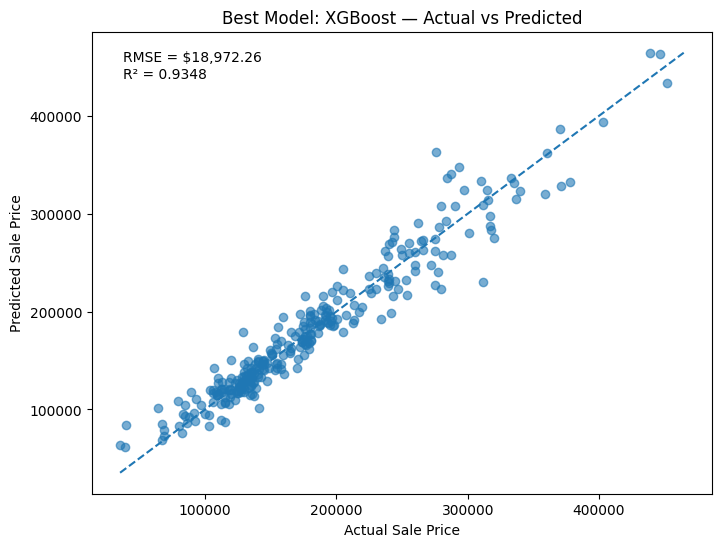

In [174]:
plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    xgb_pred,
    alpha=0.6
)

minimum = min(
    actual.min(),
    xgb_pred.min()
)

maximum = max(
    actual.max(),
    xgb_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title(
    "Best Model: XGBoost — Actual vs Predicted"
)

plt.text(
    0.05,
    0.90,
    f"RMSE = ${xgb_rmse:,.2f}\nR² = {xgb_r2:.4f}",
    transform=plt.gca().transAxes
)

plt.show()

### Interpretation

Most XGBoost predictions are close to the diagonal reference line, indicating that the predicted house prices are generally close to the actual sale prices.

The model achieves an R² score of **0.9334**, demonstrating strong predictive performance on the held-out test dataset.

# Final Conclusion

In this project, an end-to-end supervised machine learning workflow was implemented for residential house price prediction using the Ames Housing Dataset.

The project included:

- Exploratory Data Analysis
- Missing Value Analysis
- Target Variable Analysis
- Log Transformation of SalePrice
- Outlier Detection and Removal
- Feature Engineering
- Missing Value Imputation
- Numerical Feature Scaling
- Ordinal Encoding
- One-Hot Encoding
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- XGBoost Regression
- 5-Fold Cross-Validation
- Hyperparameter Tuning using RandomizedSearchCV
- Model Evaluation and Comparison

Among all evaluated models, **XGBoost achieved the best overall performance on the held-out test dataset**.

## Best Model Performance

- **Model:** XGBoost
- **RMSE:** $19,185.53

- **MAE:** $13,638.48
- **R² Score:** 0.9334
- **Training Time:** Approximately 4.05 seconds

The R² score indicates that XGBoost explains approximately **93.34% of the variation in house sale prices**.

Although hyperparameter tuning was performed using RandomizedSearchCV, the Tuned XGBoost model did not outperform the original XGBoost configuration on the held-out test dataset.

Therefore, **XGBoost was selected as the final best-performing model for this House Price Prediction project**.